# Tactical Asset Allocation & Risk Mitigation Strategy Using Hidden Markov Model

**Objective**: This project implements a tactical asset allocation strategy using Hidden Markov Models (HMM). The HMM detects latent market regimes which are mapped to an asset-switching logic (SPY/Cash). This strategy effectively mitigates tail-risk and improves portfolio efficiency during high-volatility environments.

## Core Components of the HMM

* **The Hidden States ($S$):** We define two latent states:
    * **State 0 (Calm):** Characterized by steady growth and low volatility.
    * **State 1 (Volatile):** Characterized by erratic price action and high volatility.
* **Observed Variables ($O$):** In our case, the model looks at two specific features:
    1.  Daily Log Returns (SPY)
    2.  Rolling Volatility (20-day)
* **Emission Probabilities:** We use a Gaussian HMM, which assumes that within each state, the observed data follows a Multivariate Normal Distribution.



---

## The Transition Matrix
The transition matrix is defined as follows:

| From \ To | State 0 (Low Vol) | State 1 (High Vol) |
| :--- | :--- | :--- |
| **State 0** | $P(0 \to 0)$ | $P(0 \to 1)$ |
| **State 1** | $P(1 \to 0)$ | $P(1 \to 1)$ |

### Persistence:
Financial markets exhibit Volatility Clustering. This means if the market is calm today, it is mathematically likely to stay calm tomorrow. 
* High values on the diagonal indicate stable, long-lasting regimes.
* The off-diagonal values represent the daily probability of a sudden market crash or regime shift.



---

## The Tactical Strategy Logic
Once the HMM identifies the current regime, we execute a Tactical Asset Allocation strategy. We use the regime identified at the close of the previous day ($t-1$) to determine our position today to avoid look-ahead bias.

### Allocation Rules:
$$
\text{Portfolio}_t = 
\begin{cases} 
\text{Long SPY} & \text{if Regime}_{t-1} = 0 \\
\text{Cash} & \text{if Regime}_{t-1} = 1 
\end{cases}
$$

---
## Training and Backtesting
The HMM is trained on the close prices of SPY from 2010-01-01 to 2024-12-31.
The strategy is then backtested using test data from 2025-01-01 to 2026-01-01.

### Performance & Risk Metrics
To evaluate if the strategy adds value over a simple Buy and Hold benchmark, we track:
* Annual Return
* Annual Volatility
* Sharpe Ratio 
* Max Drawdown 
* CVaR (95%) 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# DATA ACQUISITION & PREPROCESSING

def get_data():
    tickers = ["SPY"]
    df = yf.download(
        tickers,
        start="2010-01-01",
        end="2026-01-01",
        progress=False
    )["Close"]

    returns = np.log(df / df.shift(1)).dropna()
    return df, returns


# HMM MODEL TRAINING AND BACKTESTING

def run_hmm(returns):
    data = returns[["SPY"]].copy()
    data["Vol"] = data["SPY"].rolling(20).std()
    data = data.dropna()

    train_data = data.loc[:"2024-12-31"]
    test_data = data.loc["2025-01-01":"2026-01-01"]

    model = GaussianHMM(
        n_components=2,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )
    model.fit(train_data)

    train_states = model.predict(train_data)

    state_order = train_data.groupby(train_states)["SPY"].std().sort_values().index.tolist()
    state_map = {state: idx for idx, state in enumerate(state_order)}

    full_data = pd.concat([train_data, test_data])
    regimes = []
    train_len = len(train_data)

    for offset in range(len(test_data)):
        observed = full_data.iloc[:train_len + offset]
        inferred_states = model.predict(observed)
        regimes.append(state_map[inferred_states[-1]])

    results = returns.loc[test_data.index].copy()
    results["Regime"] = regimes

    reordered_transmat = model.transmat_[state_order][:, state_order]

    return results, model, reordered_transmat


# RISK & PERFORMANCE METRICS

def calculate_metrics(rets):
    def max_dd(log_rets):
        cum = np.exp(log_rets.cumsum())
        peak = cum.expanding(min_periods=1).max()
        return ((cum - peak) / peak).min()

    def cvar_95(log_rets):
        var_95 = np.percentile(log_rets, 5)
        avg_log_loss = log_rets[log_rets <= var_95].mean()
        return np.exp(avg_log_loss) - 1

    ann_ret = np.exp(rets.mean() * 252) - 1
    ann_vol = rets.std() * np.sqrt(252)
    sharpe = rets.mean() / rets.std() * np.sqrt(252)

    summary = {
        "Annual Return (%)": ann_ret * 100,
        "Annual Vol (%)": ann_vol * 100,
        "Sharpe Ratio": sharpe,
        "Max Drawdown (%)": max_dd(rets) * 100,
        "CVaR 95% (%)": cvar_95(rets) * 100
    }
    return pd.Series(summary)


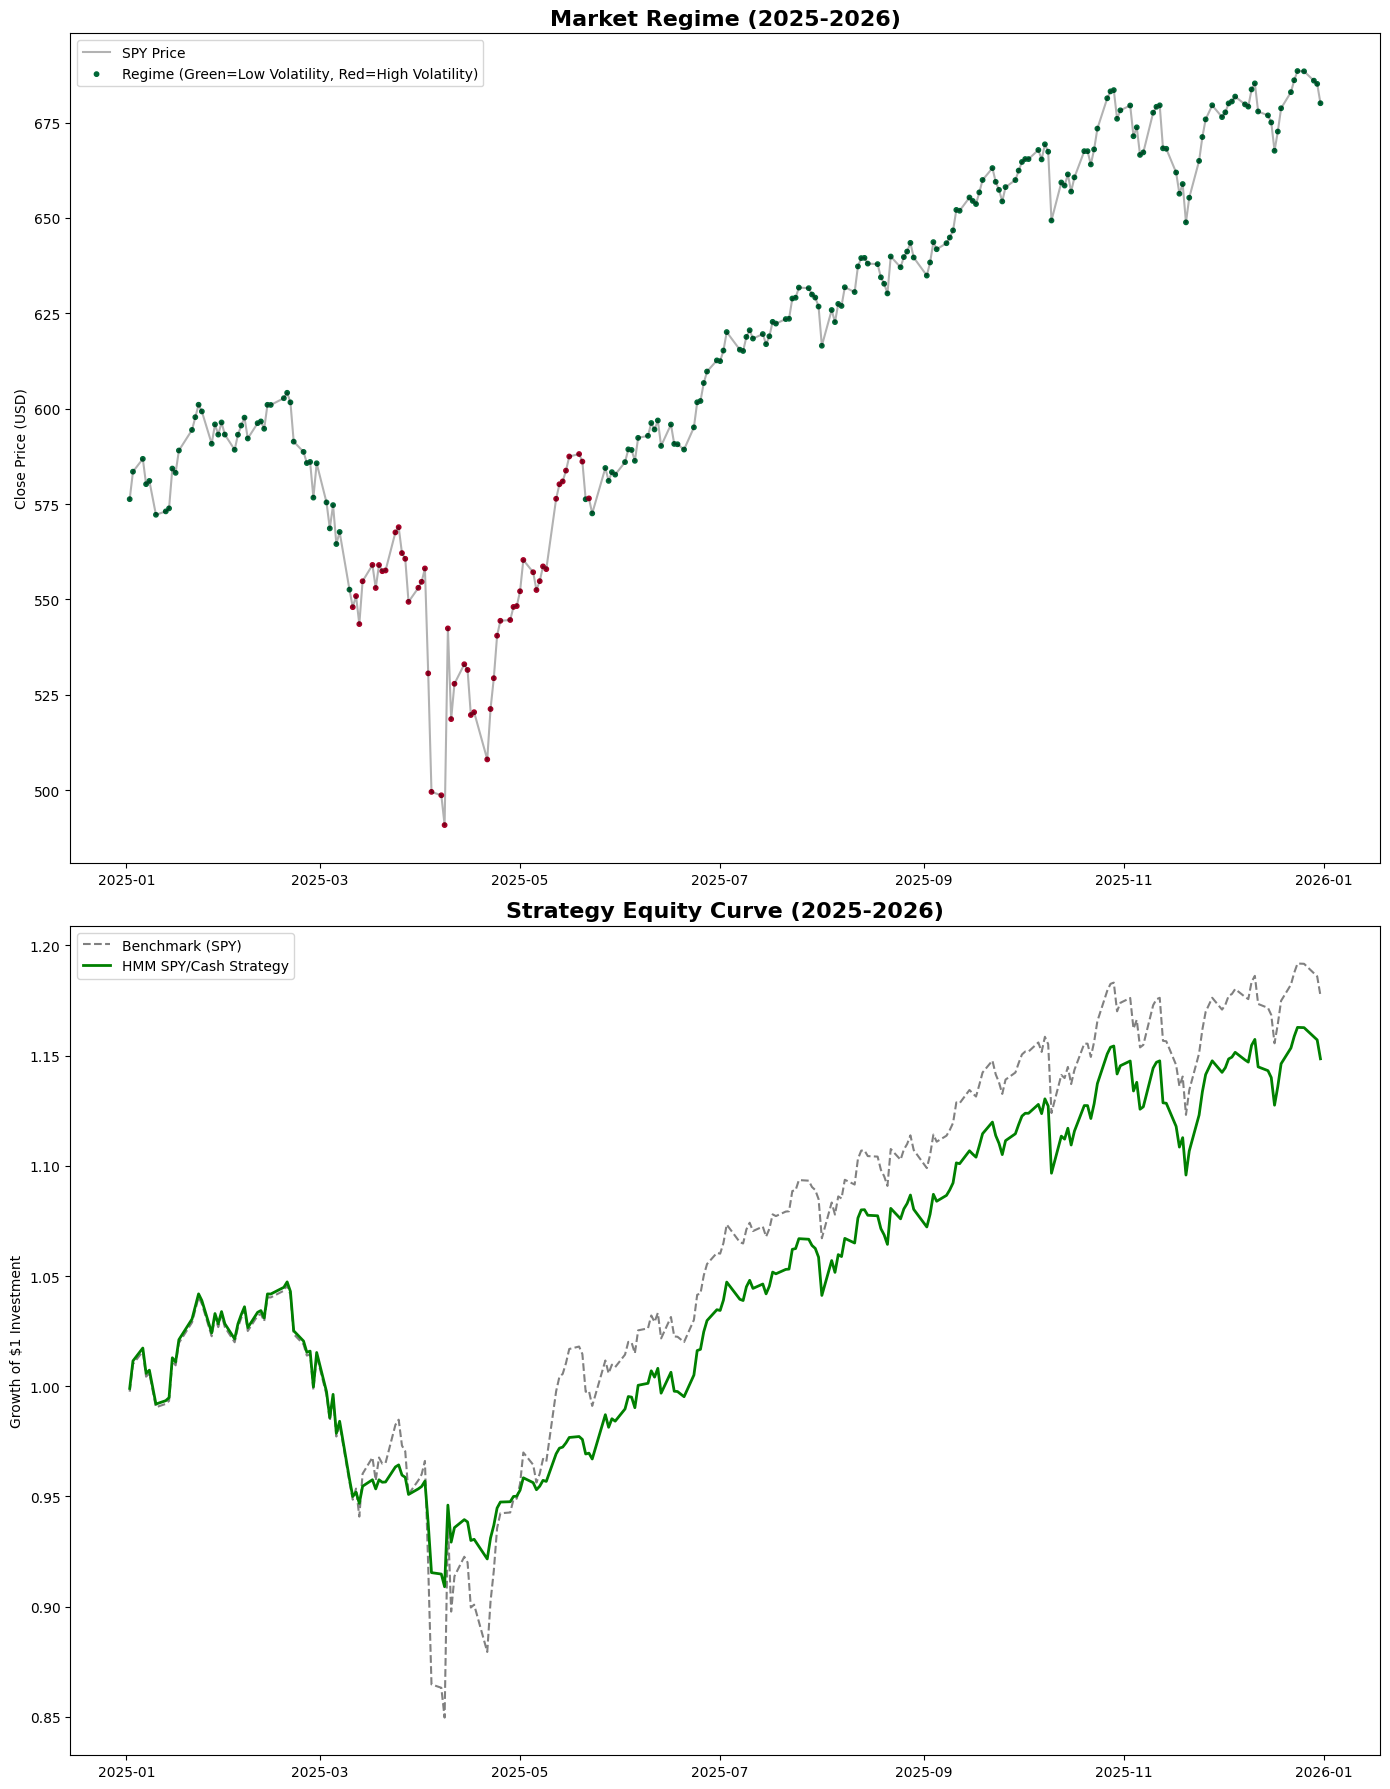


STATE TRANSITION MATRIX
               To Low Vol  To High Vol
From Low Vol       0.9948       0.0052
From High Vol      0.0188       0.9812

FINAL PERFORMANCE COMPARISON ON OUT-OF-SAMPLE DATA (2025-2026)
                   Benchmark (SPY)  HMM SPY/Cash Strategy
Annual Return (%)            17.87                  14.98
Annual Vol (%)               19.33                  12.63
Sharpe Ratio                  0.85                   1.11
Max Drawdown (%)            -18.76                 -13.21
CVaR 95% (%)                 -2.76                  -1.90


In [2]:
# MAIN

prices, returns = get_data()
results, hmm_model, transmat = run_hmm(returns)

trans_mat = pd.DataFrame(
    transmat,
    columns=["To Low Vol", "To High Vol"],
    index=["From Low Vol", "From High Vol"]
)

results["Equity_Weight"] = np.where(results["Regime"].shift(1) == 0, 1.0, 0.4)
results["Cash_Weight"] = 1.0 - results["Equity_Weight"]

results["Strategy_Ret"] = results["Equity_Weight"] * results["SPY"]

results = results.dropna()

bench_perf = calculate_metrics(results["SPY"])
strat_perf = calculate_metrics(results["Strategy_Ret"])
comparison = pd.DataFrame({
    "Benchmark (SPY)": bench_perf,
    "HMM SPY/Cash Strategy": strat_perf
})

# VISUALIZATION DASHBOARD

fig, axes = plt.subplots(2, 1, figsize=(14, 18))

# Plot Regimes
axes[0].plot(
    prices.loc[results.index].index,
    prices.loc[results.index, "SPY"],
    color="black",
    alpha=0.3,
    label="SPY Price"
)

axes[0].scatter(
    results.index,
    prices.loc[results.index, "SPY"],
    c=results["Regime"],
    cmap="RdYlGn_r",
    s=10,
    label="Regime (Green=Low Volatility, Red=High Volatility)"
)

axes[0].set_title("Market Regime (2025-2026)", fontsize=16, fontweight="bold")
axes[0].set_ylabel("Close Price (USD)")
axes[0].legend()

# Plot Cumulative Returns
strat_cum = np.exp(results["Strategy_Ret"].cumsum())
bench_cum = np.exp(results["SPY"].cumsum())

axes[1].plot(bench_cum, label="Benchmark (SPY)", color="gray", linestyle="--")
axes[1].plot(strat_cum, label="HMM SPY/Cash Strategy", color="green", linewidth=2)
axes[1].set_title("Strategy Equity Curve (2025-2026)", fontsize=16, fontweight="bold")
axes[1].set_ylabel("Growth of $1 Investment")
axes[1].legend()


plt.tight_layout()
plt.show()

print("\nSTATE TRANSITION MATRIX")
print(trans_mat.round(4))

print("\nFINAL PERFORMANCE COMPARISON ON OUT-OF-SAMPLE DATA (2025-2026)")
print(comparison.round(2))

## Conclusion

The Hidden Markov Model (HMM) has successfully identified distinct market regimes and facilitated a risk-managed investment approach.

---

### Volatility Clustering
The Transition Matrix provides strong evidence for Volatility Clustering. The model shows that market regimes are not random but highly persistent:

* **State 0 (Low Volatility):** Has a **99.48%** probability of remaining at the low volatility state the following day.
* **State 1 (High Volatility):** Has a **98.12%** probability of remaining at the high volatility state.


---


### Performance 
The switching strategy outperformed the benchmark during the high volatility region of the backtesting period. While the benchmark produced a higher absolute terminal annual return (17.87% vs. 13.88%), the Tactical Strategy traded-off the return for lower risk exposure as shown by the metrics below:

* **Volatility Compression:** Annual Volatility was reduced from **19.33%** to **12.63%**.
* **Sharpe Ratio Boost:** The Sharpe Ratio improved from **0.85** to **1.11**—a **30% increase** in risk-adjusted returns.



---

### Tail-Risk Mitigation
By rotating out of equities during high-volatility regimes, the strategy improved the CVaR(95%) from **-2.76%** to **-1.90%**. 

This means that during the worst 5% of market days, the tactical strategy preserved more capital.